This example shows a simulation of a DX7-inspired 2-operator FM synthesizer.
The implementation is based on three classes:

- **Envelope Class**
- **Operator Class**
- **Synthesizer Class**

This class structure allows the programming of the synth with different *alorithms*, that define the signal flow between the operators.

-----

# Envelope Class

The `DX7Envelope` class emulates the envelope generator of the DX7 synthesizer. 
It includes **four levels** (Attack, Decay, Sustain, and Release) and **four rates** - the corresponding durations. 
The `generate()` function creates the envelope over a specified duration.


In [122]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [123]:
class DX7Envelope:
    
    """DX7-Style Envelope with 4 Levels and 4 Times"""
    def __init__(self, levels=[1.0, 0.8, 0.5, 0.0], times=[0.1, 0.3, 0.5, 0.7], fs=48000):
        self.fs = fs
        self.set_envelope(levels, times)

    def set_envelope(self, levels, times):
        """Set DX7 envelope levels and times dynamically"""
        if len(levels) != 4 or len(times) != 4:
            raise ValueError("DX7 envelopes must have exactly 4 levels and 4 times.")
        self.levels = levels
        self.times = times

    def generate(self, duration):
        """Generate the envelope over the given duration"""
        total_samples = int(self.fs * duration)
        env = np.zeros(total_samples)

        # Convert times to sample counts
        time_samples = [int(t * self.fs) for t in self.times]

        # Build the envelope shape
        start_idx = 0
        
        # Attack phase (Starts at 0 and ramps to first level)
        end_idx = start_idx + time_samples[0]
        env[start_idx:end_idx] = np.linspace(0, self.levels[0], end_idx - start_idx)
        start_idx = end_idx

        # Decay phase (from level 1 to level 2)
        end_idx = start_idx + time_samples[1]
        env[start_idx:end_idx] = np.linspace(self.levels[0], self.levels[1], end_idx - start_idx)
        start_idx = end_idx

        # Sustain phase (constant level)
        end_idx = start_idx + time_samples[2]
        env[start_idx:end_idx] = self.levels[1]  # Sustain stays constant
        start_idx = end_idx

        # Release phase (from sustain level to 0)
        release_idx = sum(time_samples[0:-1])
        env[release_idx:] = np.linspace(self.levels[1], self.levels[3], total_samples - release_idx)

        return env


## Example Envelope

The following plot shows an example envelope with a slight attack, medium decay, a strong sustain and a long release segment:

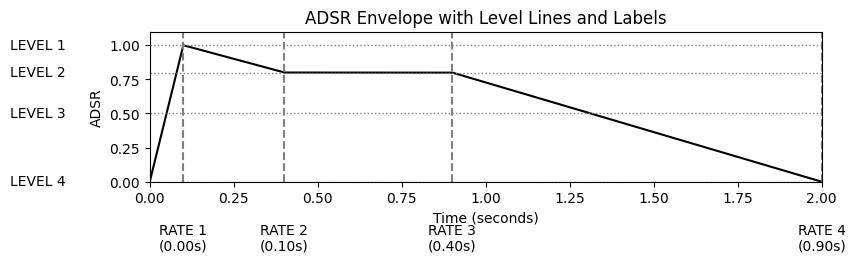

In [124]:
# Create an ADSR envelope
levels = [1.0, 0.8, 0.5, 0.0]  # Levels: Attack, Decay, Sustain, Release
times  = [0.1, 0.3, 0.5, 0.7]   # Durations: Attack, Decay, Sustain, Release

# Initialize DX7 envelope
adsr = DX7Envelope(levels=levels, times=times)
# Generate the envelope (2 seconds duration)
duration = 2.0
env = adsr.generate(duration)




# Plot the ADSR envelope with markers and level lines
t = np.linspace(0, duration, len(env))

plt.figure(figsize=(8, 3))
plt.plot(t, env, label="ADSR Envelope", color='k')
plt.title("ADSR Envelope with Level Lines and Labels")
plt.xlabel("Time (seconds)")
plt.ylabel("ADSR")

# Mark the phases with labels
phase_labels = ["RATE 1", "RATE 2", "RATE 3", "RATE 4"]
time_labels = [0, times[0], times[0] + times[1], times[0] + times[1] + times[2], duration]
level_labels = [levels[0], levels[1], levels[1], levels[3]]

# Add markers for each phase change
for i, label in enumerate(phase_labels):
    plt.axvline(x=time_labels[i+1], color='gray', linestyle='--', label=label)
    plt.text(time_labels[i+1], -0.5, f'{label}\n({time_labels[i]:.2f}s)', horizontalalignment='center')

# Plot the level lines (horizontal lines at each level)
for i, level in enumerate(levels):
    plt.axhline(y=level, color='gray', linestyle=':', linewidth=1)  # Horizontal line at the level
    plt.text(-0.25, level, "LEVEL "+str(i+1), verticalalignment='center', horizontalalignment='right')

#plt.legend()
plt.tight_layout()
plt.xlim([0,2])
plt.ylim([0,1.1])
plt.show()

----

# Operator Class

The `FMOperator` class simulates a single FM operator, similar to the ones used in the DX7.
It generates a sine wave signal that can optionally be modulated by another operator. 
The `generate()` function creates the modulated signal based on the operator's frequency, modulation index, and the envelope.


In [125]:

class FMOperator:
    
    def __init__(self, frequency, fs=48000, envelope=None, mod_index=1.0):
        self.frequency = frequency
        self.fs = fs
        self.mod_index = mod_index
        self.envelope = envelope if envelope else DX7Envelope()

    def generate(self, duration, modulator=None):
        t = np.linspace(0, duration, int(self.fs * duration), endpoint=False)
        env = self.envelope.generate(duration)

        mod_signal = modulator.generate(duration) * self.mod_index if modulator else np.zeros_like(t)
        signal = np.sin(2 * np.pi * self.frequency * t + 2 * np.pi * mod_signal)

        return signal * env


-----

# Synth Class

The `DX7Synth` class combines two FM operators, each with its own frequency, envelope, and modulation index. The class allows for the creation of a synthesis patch and generates the final output by combining the signals from the operators according to a modulation algorithm.


In [126]:

class DX7Synth:
    
    def __init__(self, fs=48000):
        self.fs = fs
        self.operators = [FMOperator(frequency=440, fs=fs) for _ in range(2)]  # 2 operators
        self.current_algorithm = [[0, 1]] 
        self.current_note = None

    def set_patch(self, freqs, envelopes, mod_indices):        
        for i in range(2):  # Adjust to 2 operators
            self.operators[i].frequency = freqs[i]
            self.operators[i].envelope = envelopes[i]
            self.operators[i].mod_index = mod_indices[i]

    def generate(self, duration):
        op_outputs = [op.generate(duration, modulator=self.operators[0]) for op in self.operators]

        # Combine outputs based on the algorithm
        final_output = np.zeros_like(op_outputs[0])

        # Apply the modulation algorithm
        for mod, carrier in self.current_algorithm:
            final_output += op_outputs[carrier]  # Carrier adds modulated signal to final output

        return final_output


-----

# Programming a Metallic Sound

We will use the two operatores to create a metallic sound,
with the *algorithm* shown in the following flowchart.

- OP1:
    - Has a fixed frequency $f_1$.
    - Is not being modulated ($I_1$ has no effect).
    - Its amplitude is controlled by ADSR$_1$
- OP2:
    - Has a central frequency $f_2$.
    - Is modulated by the output of OP1.
    - The modulation index $I_2$ determindes the strenght of the modulation.
    - The ADSR$_1$ determines the amplitude envelope of the final output.

Both envelopes are triggered at the same instance - denoted as $T$, for trigger.

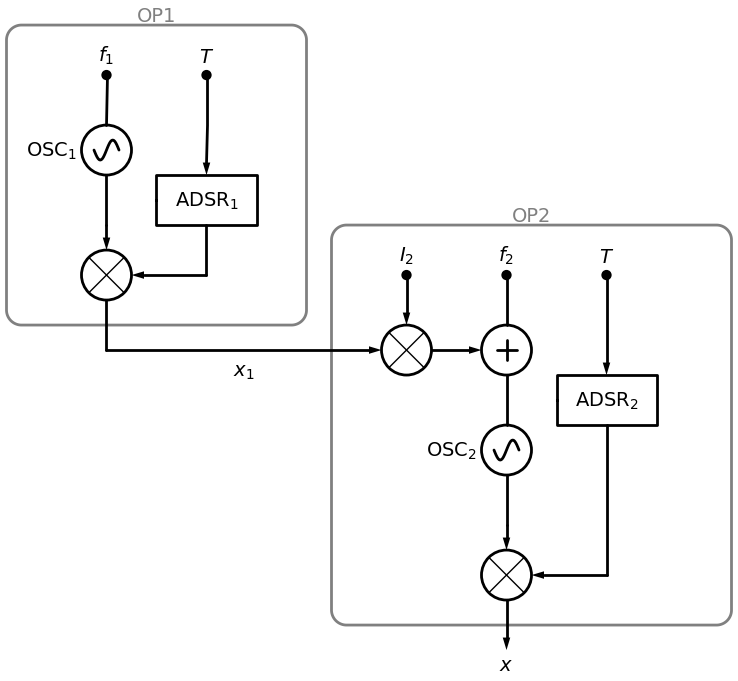

In [127]:
import schemdraw
import schemdraw.elements as elm
import schemdraw.elements as e
import schemdraw.dsp as dsp
import schemdraw.flow as flow


with schemdraw.Drawing() as d:


    # Draw a rectangle (block) manually around the elements
    flow.RoundBox( w=6, h=6, color='gray').at((0,0)).label('OP1', loc='top')

    # Modulator (FM Operator 1)
    e.Dot().at((2, 2)).label('$f_1$')
    elm.SourceSin().down().label("OSC$_1$")
    elm.Arrow().down().length(0.5)
    m1 = dsp.Mixer()

    e.Dot().at((4, 2)).label('$T$')
    elm.Arrow().down().length(2)
    b1 = dsp.Box(w=2, h=1).anchor('N').label("ADSR$_1$")
    elm.Line().down().at(b1.S).length(1).toy(m1.N)
    elm.Arrow().left().tox(m1.N)
  



    # Draw a rectangle (block) manually around the elements
    b2 = flow.RoundBox( w=8, h=8, color='gray').at((14.5,-5)).label('OP2', loc='top')

    # Modulator (FM Operator 1)
    e.Dot().at((10, -2)).label('$f_2$')
    elm.Line().down().length(1)
    dsp.Sum()
    elm.SourceSin().down().label("OSC$_2$")
    elm.Arrow().down().length(0.5)
    m2 = dsp.Mixer()

    e.Dot().at((12, -2)).label('$T$')
    elm.Arrow().down().length(2)
    b2 = dsp.Box(w=2, h=1).anchor('N').label("ADSR$_2$")
    elm.Line().down().at(b2.S).length(1).toy(m2.N)
    elm.Arrow().left().tox(m2.N)

    e.Dot().at((8, -2)).label('$I_2$')
    elm.Arrow().down().length(1)
    m3 = dsp.Mixer()
        
    e.Line().at(m1.E).down().length(1)
    elm.Arrow().right().length(5.5).label('$x_1$',loc='bottom')
    elm.Arrow().at(m3.N).right().length(1)

    elm.Arrow().at(m2.E).down().length(1).label('$x$',loc='left')
    
 
    
    d.draw()  # Display the diagram


In [56]:


freqs = [750, 955]       # operators are not in harmonic ratio to create metallic sound
mod_indices = [0.0, 1.0]  
envelopes = [
    DX7Envelope([1.0, 0.2, 0.1, 0.05], [0.0, 0.4, 0.1, 0.25], fs=48000),   
    DX7Envelope([1.0, 0.2, 0.3, 0], [0.0, 0.2, 0.11, 0.123], fs=48000), 
]

synth = DX7Synth()

# Set the patch
synth.set_patch(freqs, envelopes, mod_indices)

duration = 1.5
sound    = synth.generate(duration)




## Plotting Spectrograms and Envelopes

We can visualize the different stages by
plotting the spectrograms of the operators and the final output, 
next to the operators' envelopes.
While the operators' spectrograms show only one horizontal line for their frequency,
the final spectrogram shows decazing overtones, caused by the trajectory of ADSR$_1$.


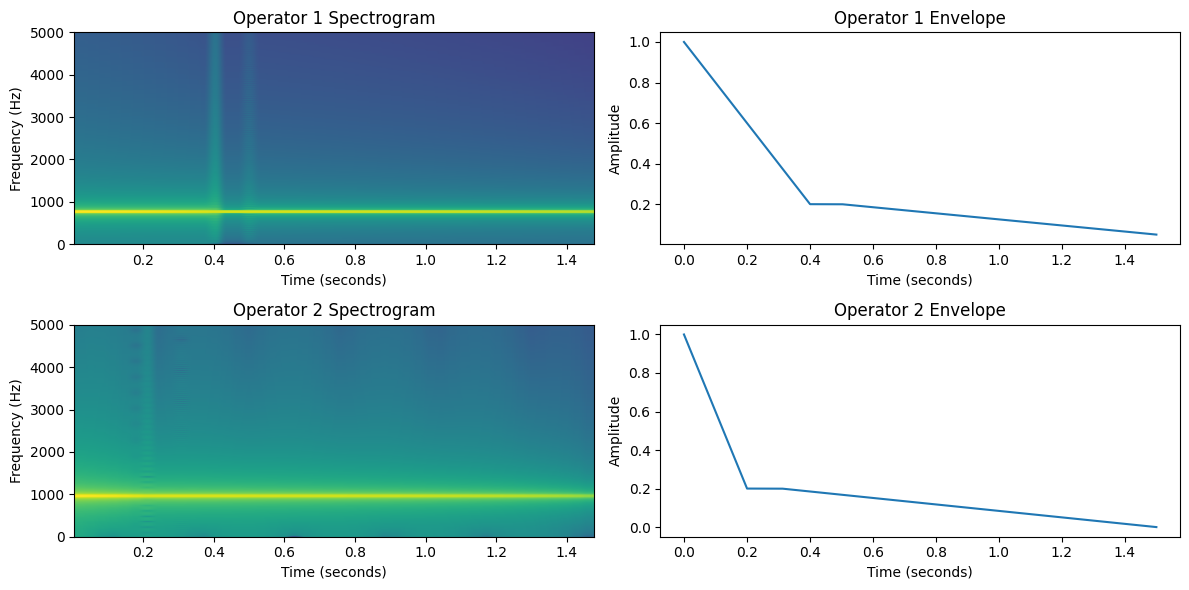

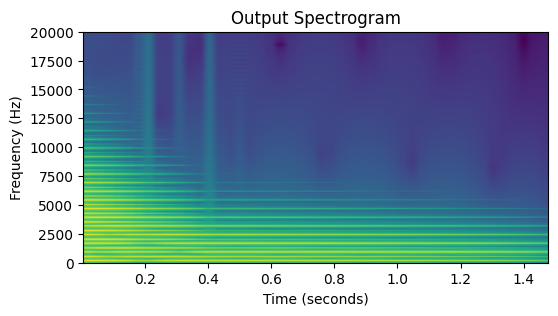

In [121]:
# Time axis for plotting
t = np.linspace(0, duration, int(synth.fs * duration), endpoint=False)

# Create a plot for each operator's spectrogram and envelope
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Plot the spectrogram and envelope for each operator
for i in range(2):
    # Generate the operator's signal
    op_signal = synth.operators[i].generate(duration)
    
    # Plot the spectrogram of the operator
    axes[i, 0].specgram(op_signal, NFFT=2*1024, Fs=synth.fs, noverlap=512)
    axes[i, 0].set_title(f"Operator {i+1} Spectrogram")
    axes[i, 0].set_xlabel("Time (seconds)")
    axes[i, 0].set_ylabel("Frequency (Hz)")
    axes[i, 0].set_ylim([0,5000])
    
    # Plot the envelope of the operator
    envelope = envelopes[i].generate(duration)
    axes[i, 1].plot(t, envelope)
    axes[i, 1].set_title(f"Operator {i+1} Envelope")
    axes[i, 1].set_xlabel("Time (seconds)")
    axes[i, 1].set_ylabel("Amplitude")
    

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(6, 3))

plt.specgram(sound, NFFT=2*1024, Fs=synth.fs, noverlap=512)
# Plot the final output spectrogram
plt.title("Output Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.ylim([0,20000])

plt.show()


-----

## Resulting Sound

The resulting sound has the metallic sound, that is characteristic for FM synthesis:
 

In [55]:
from IPython.display import Audio
Audio(sound, rate=synth.fs)